# Geophysical Inversion
## Homework 3
## Magnús Pálsson

### Problem 2

Suppose that you determine the masses of 100 objects by weighing the first, then weighing the first and second together, and then weighing the
rest in triplets: the first, second, and third; the second, third, and fourth; and so forth.
Write a script that 

(A) randomly assigns masses $m_i^{true}$ to the objects in the range of 0–1 kg; 

(B) builds the appropriate data kernel G; 

(C) creates synthetic observed data $d^{obs}=\mathbf{Gm}+\mathbf{n}$, where $\mathbf{n}$ is a vector of Gaussian random numbers with zero mean and
$\sigma_d=0.01$ kg; 

(D) solves the inverse problem by simple least squares; 

(E) estimates the variance of each of the estimated model parameters $m^{est}$; and 

(F) counts up the number of estimated model parameters that are within $\pm 2\sigma_m$ of their true value. 

(G) Make a plot of $\sigma_m$ as a function of the index of the model parameter. Does it decline, remain constant, or grow?

100


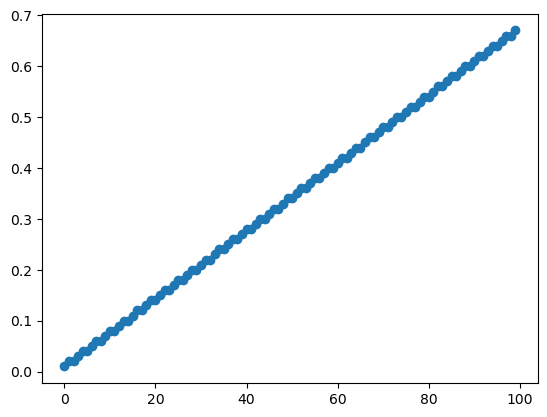

In [97]:
import numpy as np
import matplotlib.pyplot as plt
# (A)
data_size = 100
m_true = np.random.uniform(low=0.0, high=1.0, size=(data_size,1))
#(B)
G = np.diag(np.ones(data_size)) + np.diag(np.ones(data_size-1),-1) + np.diag(np.ones(data_size-2),-2)
#(C)
n = np.random.normal(loc = 0, scale=0.1, size = (data_size,1))
dobs = G.dot(m_true) + n
#(D)
m_est = np.linalg.inv(G.T.dot(G)).dot(G.T).dot(dobs)
#(E)
cov_m_est = 0.01*np.linalg.inv(G.T.dot(G))
vars_m_est = np.diag(cov_m_est)
#(F)
residuals = np.abs(m_true - m_est)
mask = residuals < 2 * np.reshape(np.sqrt(vars_m_est), shape=(data_size,1))
number = np.sum(mask)
print(number)
#(G)
plot = plt.plot(vars_m_est, 'o')

The number in (F) Varies quite a bit but generally hovers around 95. We plot variance instead of standard deviation for $\sigma_m$ since it is linear, making $\sigma_m$ grow like the sqare root of the index.

### Problem 3

Suppose that you determine the height of 50 objects by measuring the first, and then stacking the second on top of the first and measuring their combined height, stacking the third on top of the first two and measuring their combined height, and so forth. Write a script that 

(A) randomly assigns heights $m_i^{true}$ to the objects in the range of 0–1m; 

(B) builds the appropriate data kernel G; 

(C) creates synthetic observed data $d^{obs}=\mathbf{Gm}+\mathbf{n}$, where $\mathbf{n}$ is a vector of Gaussian random numbers with zero mean and
$\sigma_d=0.01$ m; 

(D) solves the inverse problem by simple least squares; 

(E) estimates the variance of each of the estimated model parameters $m^{est}$; and 

(F) counts up the number of estimated model parameters that are within $\pm 2\sigma_m$ of their true value. 

(G) Make a plot of $\sigma_m$ as a function of the index of the model parameter. Does it decline, remain constant, or grow?

49


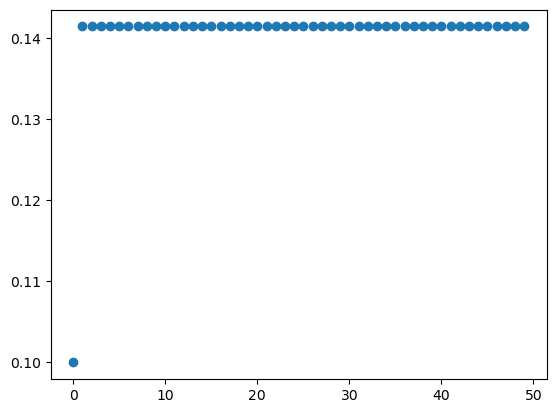

In [96]:
# (A)
data_size = 50
m_true = np.random.uniform(low=0.0, high=1.0, size=(data_size,1))
#(B)
G = np.tri(data_size)
#(C)
n = np.random.normal(loc = 0, scale=0.1, size = (data_size,1))
dobs = G.dot(m_true) + n
#(D)
m_est = np.linalg.inv(G.T.dot(G)).dot(G.T).dot(dobs)
#(E)
cov_m_est = 0.01*np.linalg.inv(G.T.dot(G))
vars_m_est = np.diag(cov_m_est)
#(F)
residuals = np.abs(m_true - m_est)
mask = residuals < 2 * np.reshape(np.sqrt(vars_m_est), shape=(data_size,1))
number = np.sum(mask)
print(number)
#(G)
plot = plt.plot(np.sqrt(vars_m_est), 'o')

The number in (F) Varies quite a bit but generally hovers around the hight 40's. $\sigma_m$ is nearly constant, with only the first element being different.